   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


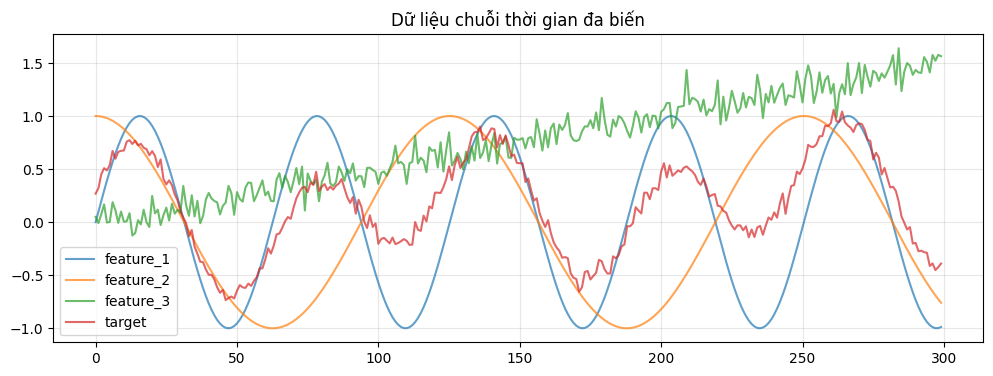

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reproducibility
torch.manual_seed(42)

# =====================
# Train / Val / Test Split
# =====================

n = len(df)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

# =====================
# Scaling (fit ONLY on train)
# =====================

feature_cols = ['feature_1', 'feature_2', 'feature_3']
target_col = 'target'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

feature_scaler.fit(train_df[feature_cols])
target_scaler.fit(train_df[[target_col]])

X_train_scaled = feature_scaler.transform(train_df[feature_cols])
X_val_scaled = feature_scaler.transform(val_df[feature_cols])
X_test_scaled = feature_scaler.transform(test_df[feature_cols])

y_train_scaled = target_scaler.transform(train_df[[target_col]])
y_val_scaled = target_scaler.transform(val_df[[target_col]])
y_test_scaled = target_scaler.transform(test_df[[target_col]])

# =====================
# Sliding Window
# =====================

seq_length = 20

def create_sequences(X, y, seq_length):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    seq_length
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    seq_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    seq_length
)

# =====================
# Convert to Tensor
# =====================

X_train_tensor = torch.FloatTensor(X_train_seq)
X_val_tensor = torch.FloatTensor(X_val_seq)
X_test_tensor = torch.FloatTensor(X_test_seq)

y_train_tensor = torch.FloatTensor(y_train_seq).reshape(-1, 1)
y_val_tensor = torch.FloatTensor(y_val_seq).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test_seq).reshape(-1, 1)

# =====================
# DataLoader
# =====================

batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

# =====================
# Shape Check
# =====================

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_val:", X_val_tensor.shape)
print("y_val:", y_val_tensor.shape)

print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

assert X_train_tensor.ndim == 3
assert X_train_tensor.shape[1] == seq_length
assert X_train_tensor.shape[2] == 3

print("\nData preprocessing completed successfully.")

X_train: torch.Size([190, 20, 3])
y_train: torch.Size([190, 1])
X_val: torch.Size([25, 20, 3])
y_val: torch.Size([25, 1])
X_test: torch.Size([25, 20, 3])
y_test: torch.Size([25, 1])

Data preprocessing completed successfully.


Epoch [010/150] | Train Loss = 0.011397 | Val Loss = 0.029739
Epoch [020/150] | Train Loss = 0.001517 | Val Loss = 0.001494
Epoch [030/150] | Train Loss = 0.001276 | Val Loss = 0.001408
Epoch [040/150] | Train Loss = 0.001191 | Val Loss = 0.001364
Epoch [050/150] | Train Loss = 0.001157 | Val Loss = 0.001349
Epoch [060/150] | Train Loss = 0.001136 | Val Loss = 0.001332
Epoch [070/150] | Train Loss = 0.001118 | Val Loss = 0.001317
Epoch [080/150] | Train Loss = 0.001104 | Val Loss = 0.001304
Epoch [090/150] | Train Loss = 0.001093 | Val Loss = 0.001295
Epoch [100/150] | Train Loss = 0.001083 | Val Loss = 0.001290
Epoch [110/150] | Train Loss = 0.001075 | Val Loss = 0.001287
Epoch [120/150] | Train Loss = 0.001067 | Val Loss = 0.001287
Epoch [130/150] | Train Loss = 0.001060 | Val Loss = 0.001288
Epoch [140/150] | Train Loss = 0.001053 | Val Loss = 0.001291
Epoch [150/150] | Train Loss = 0.001047 | Val Loss = 0.001295

Best Validation Loss = 0.001287


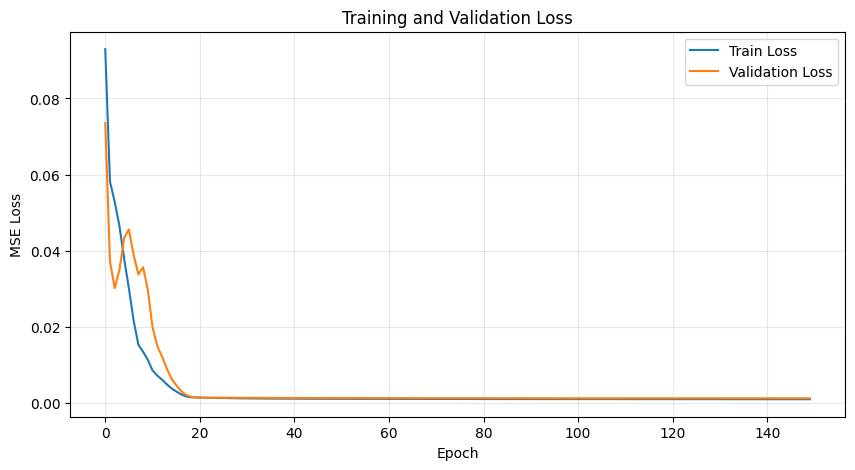

In [3]:
# =====================
# RNN Model
# =====================

class RNNRegressor(nn.Module):
    def __init__(
        self,
        input_size=3,
        hidden_size=32,
        output_size=1
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        out, _ = self.rnn(x)

        # lấy output tại timestep cuối
        last_hidden = out[:, -1, :]

        out = self.fc(last_hidden)

        return out
# =====================
# Initialize Model
# =====================

model = RNNRegressor(
    input_size=3,
    hidden_size=32,
    output_size=1
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 150

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_state = None

# =====================
# Training Loop
# =====================

for epoch in range(epochs):

    # -----------------
    # Train
    # -----------------

    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    # -----------------
    # Validation
    # -----------------

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # lưu model tốt nhất
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1:03d}/{epochs}] "
            f"| Train Loss = {train_loss:.6f} "
            f"| Val Loss = {val_loss:.6f}"
        )

# =====================
# Load Best Model
# =====================

model.load_state_dict(best_state)

print(
    f"\nBest Validation Loss = "
    f"{best_val_loss:.6f}"
)

# =====================
# Loss Curve
# =====================

plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.title(
    'Training and Validation Loss'
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

===== RNN Performance =====
MSE : 0.001952
MAE : 0.037164

===== Naive Baseline =====
MSE : 0.006933
MAE : 0.066069

===== Comparison =====


,Model,MSE,MAE
0,RNN,0.001952,0.037164
1,Naive,0.006933,0.066069


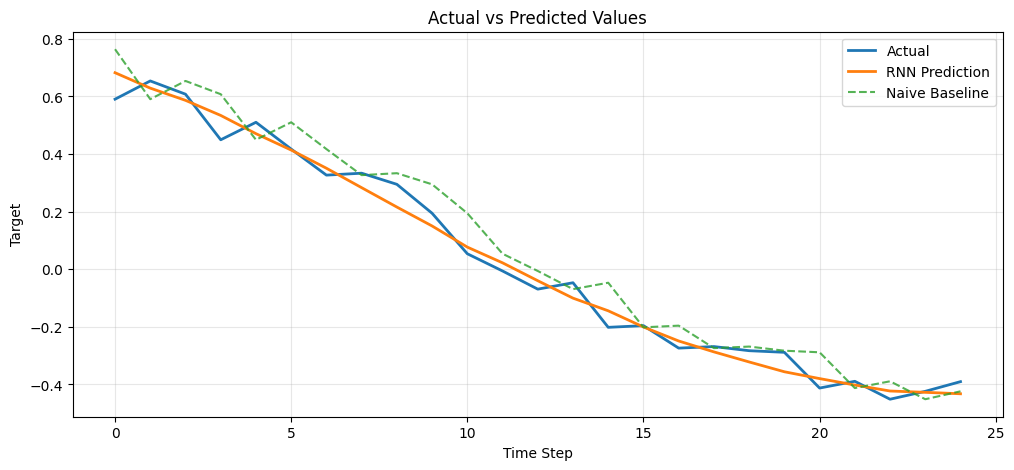

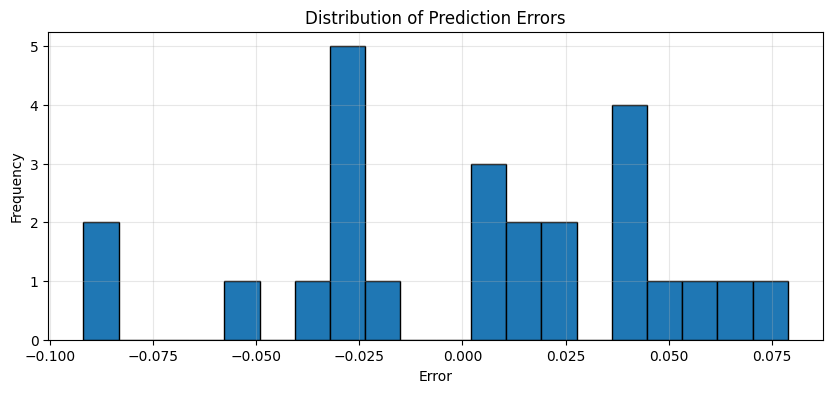

In [4]:
# =====================
# Evaluate on Test Set
# =====================

model.eval()

with torch.no_grad():

    predictions = model(
        X_test_tensor
    ).detach().numpy()

# =====================
# Inverse Transform
# =====================

y_pred = target_scaler.inverse_transform(
    predictions
)

y_true = target_scaler.inverse_transform(
    y_test_tensor.numpy()
)

# =====================
# RNN Metrics
# =====================

rnn_mse = mean_squared_error(
    y_true,
    y_pred
)

rnn_mae = mean_absolute_error(
    y_true,
    y_pred
)

print("===== RNN Performance =====")
print(f"MSE : {rnn_mse:.6f}")
print(f"MAE : {rnn_mae:.6f}")

# =====================
# Naive Baseline
# y(t+1) = y(t)
# =====================

naive_scaled = []

for i in range(len(y_test_seq)):

    last_target = y_test_scaled[
        i + seq_length - 1
    ]

    naive_scaled.append(
        last_target
    )

naive_scaled = np.array(
    naive_scaled
)

naive_pred = target_scaler.inverse_transform(
    naive_scaled
)

naive_mse = mean_squared_error(
    y_true,
    naive_pred
)

naive_mae = mean_absolute_error(
    y_true,
    naive_pred
)

print("\n===== Naive Baseline =====")
print(f"MSE : {naive_mse:.6f}")
print(f"MAE : {naive_mae:.6f}")

# =====================
# Comparison Table
# =====================

comparison_df = pd.DataFrame({
    "Model": ["RNN", "Naive"],
    "MSE": [rnn_mse, naive_mse],
    "MAE": [rnn_mae, naive_mae]
})

print("\n===== Comparison =====")
display(comparison_df)

# =====================
# Plot Prediction
# =====================

plt.figure(figsize=(12,5))

plt.plot(
    y_true,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred,
    label="RNN Prediction",
    linewidth=2
)

plt.plot(
    naive_pred,
    '--',
    label="Naive Baseline",
    alpha=0.8
)

plt.title(
    "Actual vs Predicted Values"
)

plt.xlabel("Time Step")
plt.ylabel("Target")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# =====================
# Residual Analysis
# =====================

residuals = y_true.flatten() - y_pred.flatten()

plt.figure(figsize=(10,4))

plt.hist(
    residuals,
    bins=20,
    edgecolor='black'
)

plt.title(
    "Distribution of Prediction Errors"
)

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

========== SEQ LENGTH ==========


,Seq_Length,Test_MSE
0,10,0.002195
1,20,0.002172
2,30,0.001574



========== HIDDEN SIZE ==========

Hidden Size = 16
Test MSE = 0.003704
Train Loss = 0.001362
Val Loss = 0.001575
=> Good Fit


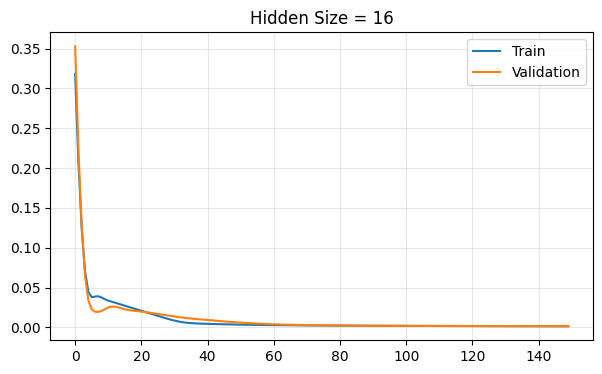


Hidden Size = 32
Test MSE = 0.001868
Train Loss = 0.001074
Val Loss = 0.001329
=> Good Fit


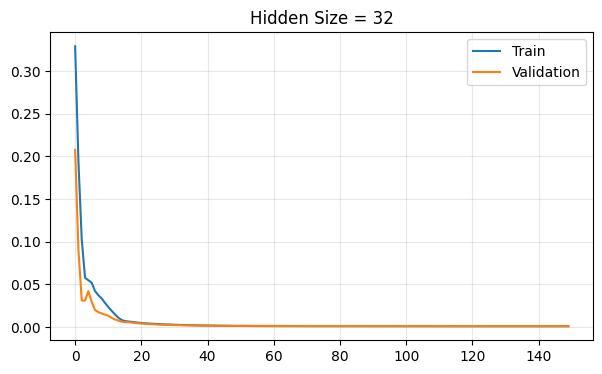


Hidden Size = 64
Test MSE = 0.002093
Train Loss = 0.001038
Val Loss = 0.001272
=> Good Fit


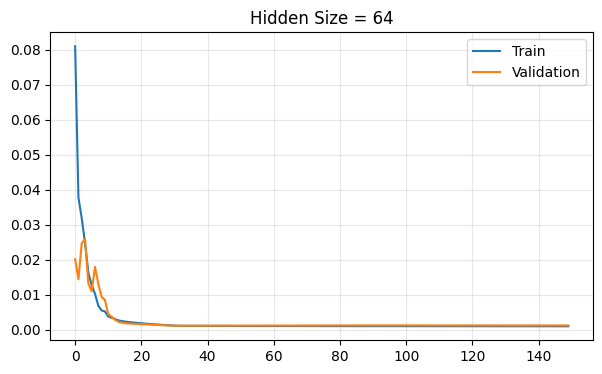


========== DROPOUT ==========
No Dropout MSE : 0.002153
Dropout MSE    : 0.002258


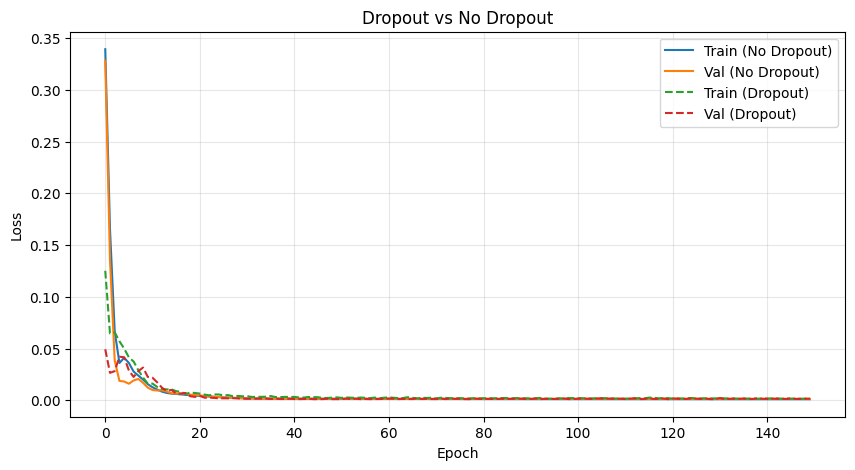

In [5]:
# ==================================================
# Helper Function
# ==================================================

def run_experiment(
    seq_length=20,
    hidden_size=32,
    dropout=0.0,
    num_layers=1,
    epochs=150
):

    # ----------------------------------
    # Create Sequences
    # ----------------------------------

    def create_sequences(X, y, seq_length):

        X_seq = []
        y_seq = []

        for i in range(len(X) - seq_length):
            X_seq.append(X[i:i+seq_length])
            y_seq.append(y[i+seq_length])

        return np.array(X_seq), np.array(y_seq)

    Xtr, ytr = create_sequences(
        X_train_scaled,
        y_train_scaled,
        seq_length
    )

    Xv, yv = create_sequences(
        X_val_scaled,
        y_val_scaled,
        seq_length
    )

    Xte, yte = create_sequences(
        X_test_scaled,
        y_test_scaled,
        seq_length
    )

    Xtr = torch.FloatTensor(Xtr)
    ytr = torch.FloatTensor(ytr).reshape(-1,1)

    Xv = torch.FloatTensor(Xv)
    yv = torch.FloatTensor(yv).reshape(-1,1)

    Xte = torch.FloatTensor(Xte)
    yte = torch.FloatTensor(yte).reshape(-1,1)

    # ----------------------------------
    # DataLoader
    # ----------------------------------

    train_loader_exp = DataLoader(
        TensorDataset(Xtr, ytr),
        batch_size=32,
        shuffle=False
    )

    val_loader_exp = DataLoader(
        TensorDataset(Xv, yv),
        batch_size=32,
        shuffle=False
    )

    # ----------------------------------
    # Model
    # ----------------------------------

    class ExperimentRNN(nn.Module):

        def __init__(self):
            super().__init__()

            self.rnn = nn.RNN(
                input_size=3,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout,
                batch_first=True
            )

            self.fc = nn.Linear(
                hidden_size,
                1
            )

        def forward(self, x):

            out, _ = self.rnn(x)

            out = out[:, -1, :]

            return self.fc(out)

    model = ExperimentRNN()

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_curve = []
    val_curve = []

    best_val = float('inf')
    best_state = None

    # ----------------------------------
    # Training
    # ----------------------------------

    for epoch in range(epochs):

        model.train()

        running_train = 0

        for xb, yb in train_loader_exp:

            optimizer.zero_grad()

            pred = model(xb)

            loss = criterion(
                pred,
                yb
            )

            loss.backward()

            optimizer.step()

            running_train += loss.item()

        train_loss = (
            running_train /
            len(train_loader_exp)
        )

        model.eval()

        running_val = 0

        with torch.no_grad():

            for xb, yb in val_loader_exp:

                pred = model(xb)

                loss = criterion(
                    pred,
                    yb
                )

                running_val += loss.item()

        val_loss = (
            running_val /
            len(val_loader_exp)
        )

        train_curve.append(train_loss)
        val_curve.append(val_loss)

        if val_loss < best_val:

            best_val = val_loss

            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

    model.load_state_dict(best_state)

    # ----------------------------------
    # Test
    # ----------------------------------

    model.eval()

    with torch.no_grad():

        pred_test = model(
            Xte
        ).numpy()

    y_pred = target_scaler.inverse_transform(
        pred_test
    )

    y_true = target_scaler.inverse_transform(
        yte.numpy()
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    return mse, train_curve, val_curve


# ==================================================
# 1. Seq Length Experiment
# ==================================================

print("========== SEQ LENGTH ==========")

seq_results = []

for seq in [10, 20, 30]:

    mse, _, _ = run_experiment(
        seq_length=seq,
        hidden_size=32
    )

    seq_results.append(
        [seq, mse]
    )

seq_df = pd.DataFrame(
    seq_results,
    columns=[
        "Seq_Length",
        "Test_MSE"
    ]
)

display(seq_df)


# ==================================================
# 2. Hidden Size Experiment
# ==================================================

print("\n========== HIDDEN SIZE ==========")

for hidden in [16, 32, 64]:

    mse, train_curve, val_curve = run_experiment(
        seq_length=20,
        hidden_size=hidden
    )

    print(
        f"\nHidden Size = {hidden}"
    )

    print(
        f"Test MSE = {mse:.6f}"
    )

    final_train = train_curve[-1]
    final_val = val_curve[-1]

    print(
        f"Train Loss = {final_train:.6f}"
    )

    print(
        f"Val Loss = {final_val:.6f}"
    )

    gap = final_val - final_train

    if final_train > 0.01 and final_val > 0.01:
        print("=> Possible UNDERFITTING")

    elif gap > 0.01:
        print("=> Possible OVERFITTING")

    else:
        print("=> Good Fit")

    plt.figure(figsize=(7,4))

    plt.plot(
        train_curve,
        label="Train"
    )

    plt.plot(
        val_curve,
        label="Validation"
    )

    plt.title(
        f"Hidden Size = {hidden}"
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()


# ==================================================
# 3. Dropout Experiment
# ==================================================

print("\n========== DROPOUT ==========")

mse_no, train_no, val_no = run_experiment(
    seq_length=20,
    hidden_size=32,
    dropout=0.0,
    num_layers=1
)

mse_do, train_do, val_do = run_experiment(
    seq_length=20,
    hidden_size=32,
    dropout=0.2,
    num_layers=2
)

print(f"No Dropout MSE : {mse_no:.6f}")
print(f"Dropout MSE    : {mse_do:.6f}")

plt.figure(figsize=(10,5))

plt.plot(
    train_no,
    label='Train (No Dropout)'
)

plt.plot(
    val_no,
    label='Val (No Dropout)'
)

plt.plot(
    train_do,
    '--',
    label='Train (Dropout)'
)

plt.plot(
    val_do,
    '--',
    label='Val (Dropout)'
)

plt.title(
    "Dropout vs No Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()